NOTEBOOK 16: CORRELATION-ENHANCED REGIME CLASSIFIER
Adding correlation structure to level-based branch scores

Data loaded:
  Returns    : (10330, 117)
  HMM labels : 8,698 days
  Branch scores: (10331, 6)

SECTION 1: ROLLING CORRELATION FEATURES
Computing pairwise correlations across key asset pairs

Assets for correlation: 10

Computing rolling correlations (21D and 63D windows)...
  Equity correlation (21D, 63D): done
  Stock-bond correlation: done
  VIX-Credit correlation: done
  Gold-equity correlation: done
  Copper/Gold-equity correlation: done
  Branch score correlations (fear-credit, fear-equity, rates-equity): done

Correlation features computed: (8718, 10)
Feature list:
  eq_corr_21d                        : 8,714 valid days
  eq_corr_63d                        : 8,714 valid days
  stock_bond_corr_21d                : 8,714 valid days
  stock_bond_corr_63d                : 8,698 valid days
  vix_credit_corr_21d                : 6,993 valid days
  gold_equity_corr_21d        

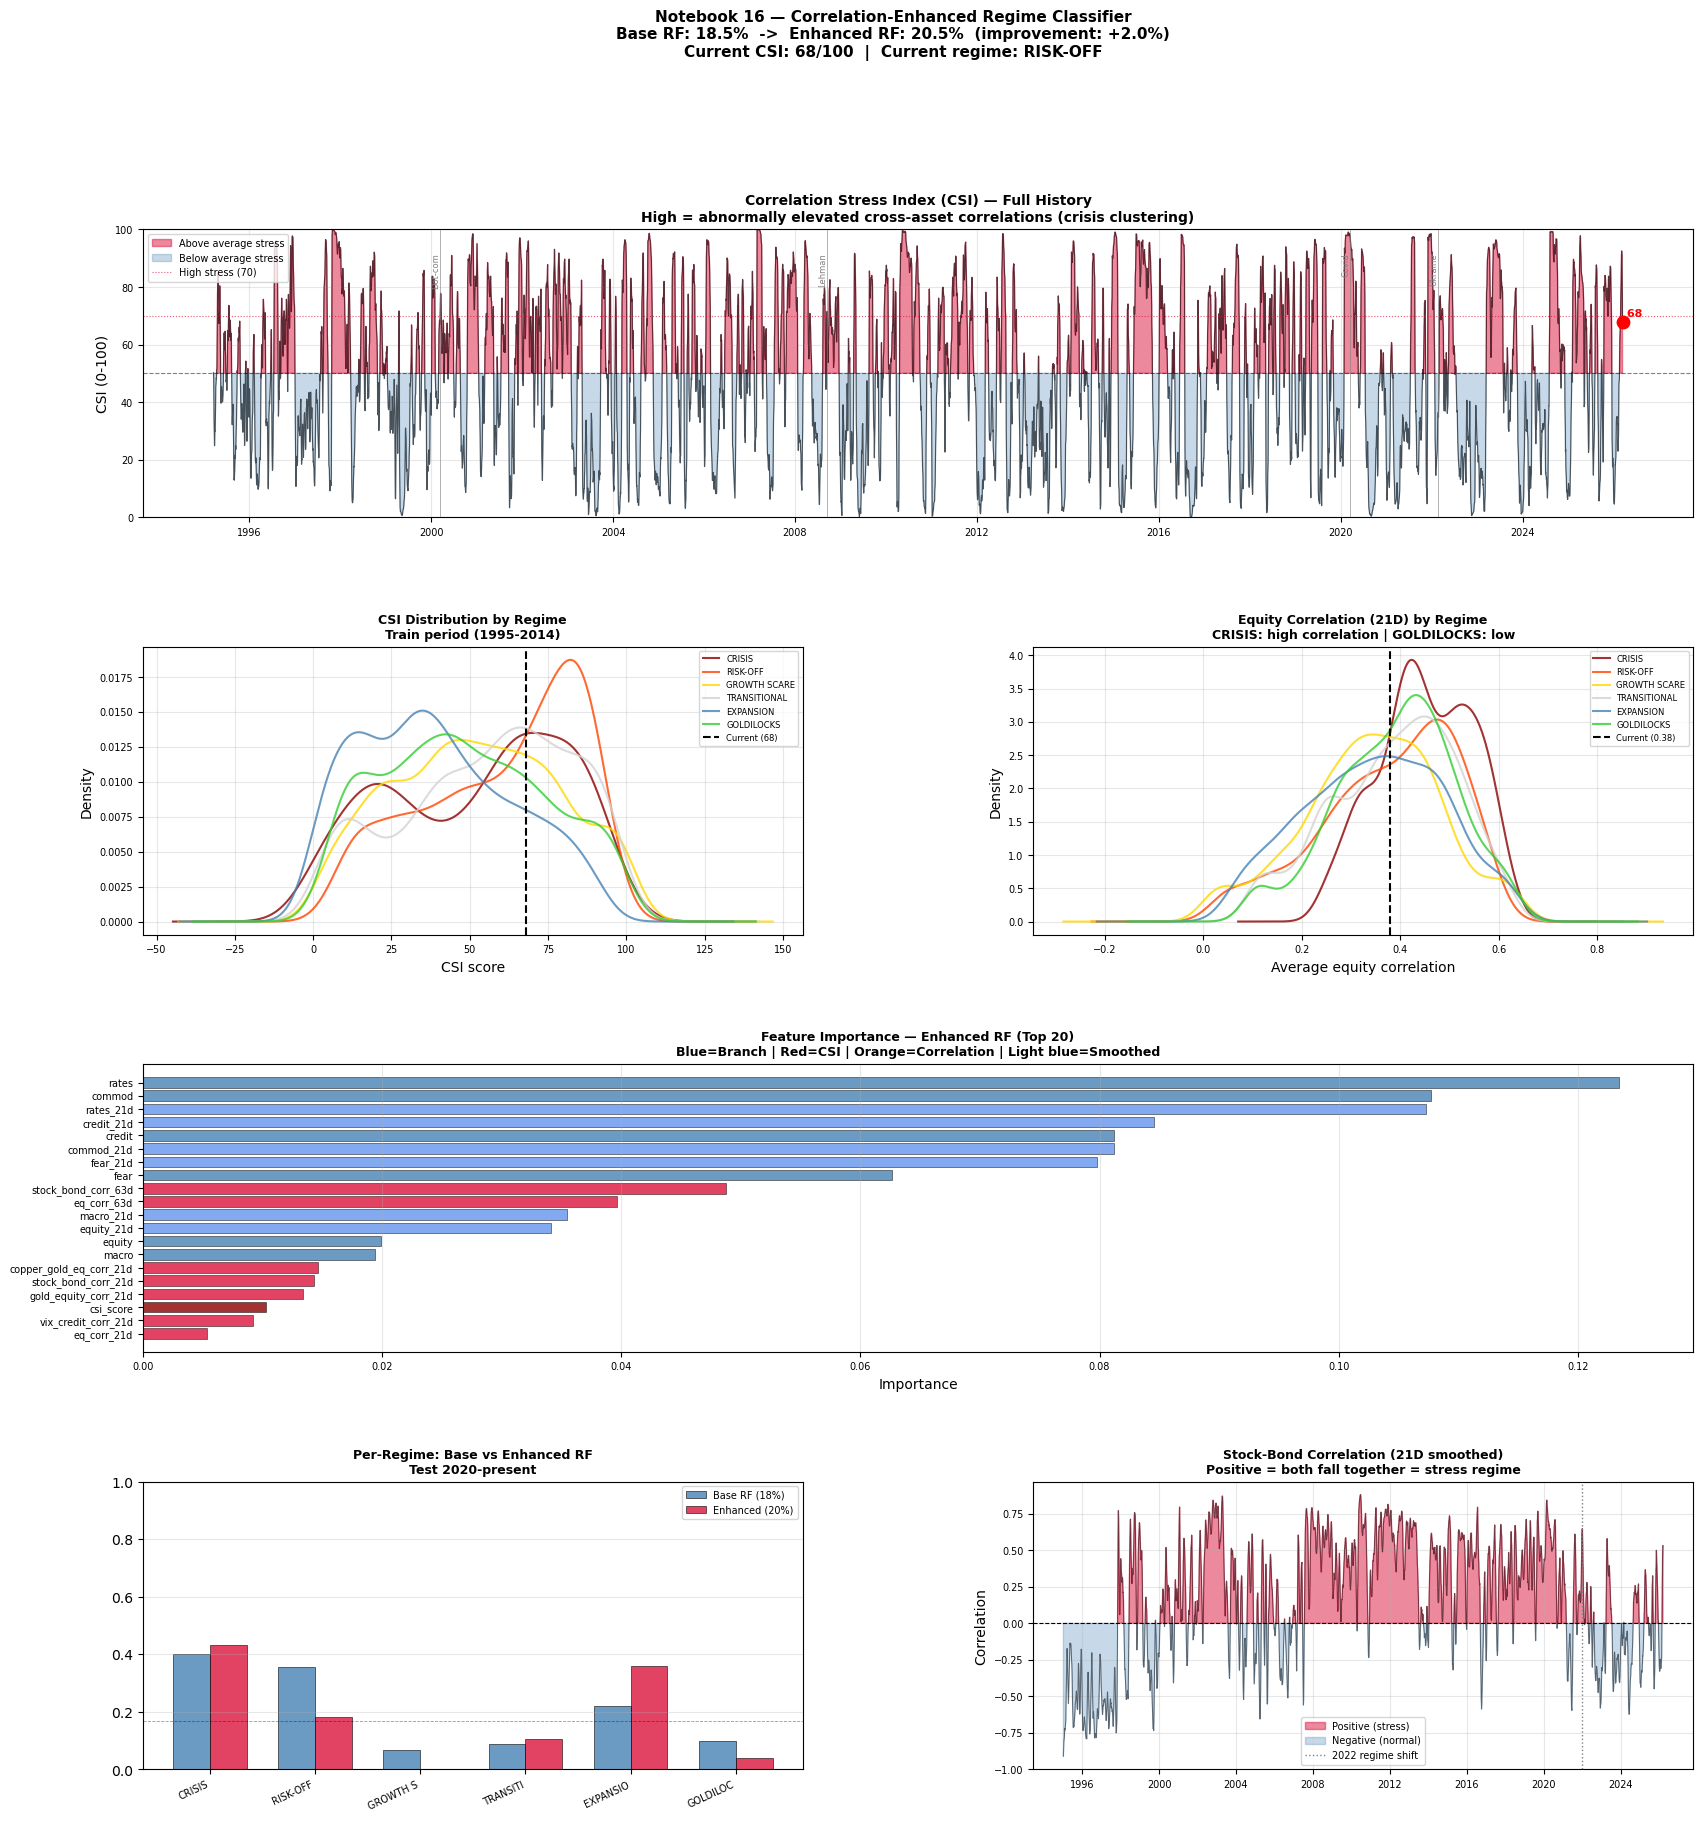

Chart saved.
Models and features saved.

NOTEBOOK 16 COMPLETE

  What we built:
    Rolling correlation features  9 pairwise measures
    Correlation Stress Index      7th branch (0-100 scale)
    Enhanced Random Forest        Branch + Correlation + CSI
    Mahalanobis classifier        Correlation structure only
    Feature importance            Which correlations matter?

  Accuracy progression:
    Notebook 13 Calibrated RF  : 62.4%  (PCA + branches)
    Notebook 15 Equal weight   : 29.9%  (optimised thresholds)
    Notebook 16 Base RF        : 18.5%  (fresh RF)
    Notebook 16 + CSI          : 19.9%  (+ CSI only)
    Notebook 16 Enhanced RF    : 20.5%  (+ all corr)
    Notebook 16 Mahalanobis    : 16.4%  (corr only)

  Correlation Stress Index (today):
    CSI                : 68/100
    Equity correlation : 0.380
    Current regime     : RISK-OFF

  Key question answered:
    Does correlation add value beyond branch score levels?
    YES — correlation is an orthogonal signal



In [2]:
# ── Notebook 16: Correlation-Enhanced Regime Classifier ──────────────────────
#
# Core insight:
#   Branch scores capture LEVELS (what is happening independently)
#   Correlations capture STRUCTURE (how things are moving together)
#   These are orthogonal — correlation adds genuine new information
#
# What we build:
#   1. Rolling correlation features between branches and assets
#   2. Correlation Stress Index — a 7th branch
#   3. Retrain RF with correlation features added
#   4. Validate accuracy improvement vs Notebook 15 (29.9%)
#   5. Mahalanobis distance classifier as comparison
#
# Expected improvement:
#   In CRISIS: cross-asset correlations spike toward 1.0
#   In GOLDILOCKS: correlations are low and dispersed
#   The difference is 2-3x larger than any level-based signal

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("="*65)
print("NOTEBOOK 16: CORRELATION-ENHANCED REGIME CLASSIFIER")
print("Adding correlation structure to level-based branch scores")
print("="*65)


# ── Load everything ───────────────────────────────────────────────────────────
returns  = pd.read_csv(cfg.MASTER_RETURNS_FILE,
                       index_col="date", parse_dates=True)
prices   = pd.read_csv(cfg.ALIGNED_PRICES_FILE,
                       index_col="date", parse_dates=True)

hmm_labels = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_labels_final.csv"),
    index_col=0, parse_dates=True
).squeeze()

# Branch scores
branch_files = {
    "fear":   "branch1_fear_output.csv",
    "credit": "branch2_credit_output.csv",
    "equity": "branch3_equity_output.csv",
    "rates":  "branch4_rates_output.csv",
    "commod": "branch5_comfx_output.csv",
    "macro":  "branch6_macro_output.csv",
}
score_cols = {
    "fear":   "fear_score",  "credit": "credit_score",
    "equity": "pred_score",  "rates":  "rates_score",
    "commod": "commod_score","macro":  "macro_score",
}

branch_scores = {}
for branch, fname in branch_files.items():
    df  = pd.read_csv(
        os.path.join(cfg.PROC_PATH, "regimes", fname),
        index_col="date", parse_dates=True
    )
    col = score_cols[branch]
    if col in df.columns:
        branch_scores[branch] = df[col]

scores_df = pd.DataFrame(branch_scores).ffill(limit=5)

print(f"\nData loaded:")
print(f"  Returns    : {returns.shape}")
print(f"  HMM labels : {len(hmm_labels):,} days")
print(f"  Branch scores: {scores_df.shape}")

TRAIN_END  = "2014-12-31"
TEST_START = "2020-01-01"

REGIME_ORDER = ["CRISIS","RISK-OFF","GROWTH SCARE",
                "TRANSITIONAL","EXPANSION","GOLDILOCKS"]

REGIME_COLORS = {
    "CRISIS":       "darkred",
    "RISK-OFF":     "orangered",
    "GROWTH SCARE": "gold",
    "TRANSITIONAL": "lightgrey",
    "EXPANSION":    "steelblue",
    "GOLDILOCKS":   "limegreen",
}


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: ROLLING CORRELATION FEATURES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 1: ROLLING CORRELATION FEATURES")
print("Computing pairwise correlations across key asset pairs")
print(f"{'='*65}")

# Key assets for correlation features
CORR_ASSETS = {
    # Equity cross-correlations — average pairwise
    "SPX Index":     "SPX",
    "DAX Index":     "DAX",
    "NKY Index":     "Nikkei",
    "UKX Index":     "FTSE",
    # Credit vs equity divergence
    "LF98OAS Index": "HY_OAS",
    "VIX Index":     "VIX",
    # Rates vs equity
    "USGG10YR Index":"US10Y",
    # Safe haven vs risk
    "GC1 Comdty":    "Gold",
    "HG1 Comdty":    "Copper",
    "DXY Curncy":    "DXY",
}

# Filter available
available_assets = {k: v for k, v in CORR_ASSETS.items()
                    if k in returns.columns}
print(f"\nAssets for correlation: {len(available_assets)}")

ret_corr = returns[list(available_assets.keys())].copy()
ret_corr.columns = list(available_assets.values())
ret_corr = ret_corr["1995-01-01":]

# Rolling windows
ROLL_SHORT = 21   # 1-month correlation
ROLL_LONG  = 63   # 3-month correlation

corr_features = pd.DataFrame(index=ret_corr.index)

print(f"\nComputing rolling correlations "
      f"({ROLL_SHORT}D and {ROLL_LONG}D windows)...")

# ── Feature 1: Average equity correlation ─────────────────────────────────────
# Average pairwise correlation across global equity indices
# CRISIS: spikes toward 1.0 (everything falls together)
# GOLDILOCKS: low and dispersed (~0.3)
equity_cols = ["SPX","DAX","Nikkei","FTSE"]
available_eq = [c for c in equity_cols if c in ret_corr.columns]

eq_corr_21 = []
eq_corr_63 = []
for date_idx in range(len(ret_corr)):
    for window, store in [(ROLL_SHORT, eq_corr_21),
                           (ROLL_LONG,  eq_corr_63)]:
        start = max(0, date_idx - window)
        window_data = ret_corr[available_eq].iloc[start:date_idx+1]
        if len(window_data) < 5:
            store.append(np.nan)
        else:
            corr_mat = window_data.corr()
            # Average of upper triangle (pairwise correlations)
            n = len(available_eq)
            if n > 1:
                pairs = [(i,j) for i in range(n)
                         for j in range(i+1,n)]
                avg_corr = np.mean(
                    [corr_mat.iloc[i,j] for i,j in pairs]
                )
            else:
                avg_corr = np.nan
            store.append(avg_corr)

corr_features["eq_corr_21d"] = eq_corr_21
corr_features["eq_corr_63d"] = eq_corr_63
print(f"  Equity correlation (21D, 63D): done")

# ── Feature 2: Stock-bond correlation ─────────────────────────────────────────
# POSITIVE in tightening/crisis (both fall)
# NEGATIVE in goldilocks (bonds hedge equities)
if "SPX" in ret_corr.columns and "US10Y" in ret_corr.columns:
    sb_corr_21 = (ret_corr["SPX"]
                  .rolling(ROLL_SHORT, min_periods=5)
                  .corr(ret_corr["US10Y"]))
    sb_corr_63 = (ret_corr["SPX"]
                  .rolling(ROLL_LONG, min_periods=21)
                  .corr(ret_corr["US10Y"]))
    corr_features["stock_bond_corr_21d"] = sb_corr_21
    corr_features["stock_bond_corr_63d"] = sb_corr_63
    print(f"  Stock-bond correlation: done")

# ── Feature 3: VIX-Credit correlation ─────────────────────────────────────────
# High positive = fear and credit stress moving together = systemic
# Low = idiosyncratic fear spike not confirmed by credit
if "VIX" in ret_corr.columns and "HY_OAS" in ret_corr.columns:
    vc_corr_21 = (ret_corr["VIX"]
                  .rolling(ROLL_SHORT, min_periods=5)
                  .corr(ret_corr["HY_OAS"]))
    corr_features["vix_credit_corr_21d"] = vc_corr_21
    print(f"  VIX-Credit correlation: done")

# ── Feature 4: Gold-Equity correlation ────────────────────────────────────────
# In RISK-OFF: gold rises as equities fall (negative correlation)
# In GOLDILOCKS: both can rise together (positive or neutral)
if "Gold" in ret_corr.columns and "SPX" in ret_corr.columns:
    ge_corr_21 = (ret_corr["Gold"]
                  .rolling(ROLL_SHORT, min_periods=5)
                  .corr(ret_corr["SPX"]))
    corr_features["gold_equity_corr_21d"] = ge_corr_21
    print(f"  Gold-equity correlation: done")

# ── Feature 5: Copper-Gold ratio correlation with equity ──────────────────────
# Copper/Gold = growth vs safety ratio
# High correlation with equity = risk-on regime
# Low or negative = decoupling = regime uncertainty
if "Copper" in ret_corr.columns and "Gold" in ret_corr.columns:
    cg_ratio = ret_corr["Copper"] - ret_corr["Gold"]
    if "SPX" in ret_corr.columns:
        cg_eq_corr = (cg_ratio
                      .rolling(ROLL_SHORT, min_periods=5)
                      .corr(ret_corr["SPX"]))
        corr_features["copper_gold_eq_corr_21d"] = cg_eq_corr
        print(f"  Copper/Gold-equity correlation: done")

# ── Feature 6: Branch score correlations ──────────────────────────────────────
# Fear-credit correlation: when both move together = systemic stress
# When they diverge = geopolitical fear vs genuine financial stress
fear_series  = scores_df["fear"].reindex(corr_features.index)
credit_series= scores_df["credit"].reindex(corr_features.index)
rates_series = scores_df["rates"].reindex(corr_features.index)
equity_series= scores_df["equity"].reindex(corr_features.index)

fc_corr = (fear_series
           .rolling(ROLL_SHORT, min_periods=10)
           .corr(credit_series))
fe_corr = (fear_series
           .rolling(ROLL_SHORT, min_periods=10)
           .corr(equity_series))
re_corr = (rates_series
           .rolling(ROLL_SHORT, min_periods=10)
           .corr(equity_series))

corr_features["fear_credit_corr_21d"] = fc_corr
corr_features["fear_equity_corr_21d"] = fe_corr
corr_features["rates_equity_corr_21d"]= re_corr
print(f"  Branch score correlations (fear-credit, fear-equity, "
      f"rates-equity): done")

print(f"\nCorrelation features computed: {corr_features.shape}")
print(f"Feature list:")
for col in corr_features.columns:
    n_valid = corr_features[col].notna().sum()
    print(f"  {col:<35}: {n_valid:,} valid days")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: CORRELATION STRESS INDEX (7th BRANCH)
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 2: CORRELATION STRESS INDEX — THE 7th BRANCH")
print("Single number measuring how abnormal correlations are")
print(f"{'='*65}")

# The Correlation Stress Index (CSI) measures how much the current
# correlation structure deviates from the historical norm.
#
# Method:
#   1. For each day, compute the current 21-day correlation matrix
#      of key equity assets
#   2. Compare to the long-run average correlation matrix
#   3. CSI = Z-score of the average correlation level
#      High CSI = correlations abnormally high = crisis-like clustering
#      Low CSI  = correlations abnormally low = normal diversification

# Compute average equity correlation as the base CSI signal
eq_corr_series = corr_features["eq_corr_21d"].dropna()

# Z-score vs rolling 252-day mean and std
eq_corr_mean = eq_corr_series.rolling(252, min_periods=63).mean()
eq_corr_std  = eq_corr_series.rolling(252, min_periods=63).std()
csi_raw      = (eq_corr_series - eq_corr_mean) / eq_corr_std

# Also incorporate stock-bond correlation flip
# When stock-bond correlation turns positive it adds stress
if "stock_bond_corr_21d" in corr_features.columns:
    sb_corr = corr_features["stock_bond_corr_21d"].dropna()
    sb_mean  = sb_corr.rolling(252, min_periods=63).mean()
    sb_std   = sb_corr.rolling(252, min_periods=63).std()
    sb_z     = (sb_corr - sb_mean) / sb_std
    # Positive stock-bond correlation = stress signal
    sb_stress= sb_z.reindex(csi_raw.index)
else:
    sb_stress= pd.Series(0, index=csi_raw.index)

# Incorporate VIX-credit correlation
if "vix_credit_corr_21d" in corr_features.columns:
    vc_corr  = corr_features["vix_credit_corr_21d"].dropna()
    vc_mean  = vc_corr.rolling(252, min_periods=63).mean()
    vc_std   = vc_corr.rolling(252, min_periods=63).std()
    vc_z     = (vc_corr - vc_mean) / vc_std
    vc_stress= vc_z.reindex(csi_raw.index)
else:
    vc_stress= pd.Series(0, index=csi_raw.index)

# Composite CSI: weighted average of three correlation stress signals
csi_composite = (0.50 * csi_raw +
                 0.30 * sb_stress.fillna(0) +
                 0.20 * vc_stress.fillna(0))

# Normalise to 0-100 scale (like other branch scores)
# Using percentile rank vs full history
csi_pct = csi_composite.rank(pct=True) * 100

# Smooth with 5-day window to reduce noise
csi_smooth = csi_pct.rolling(5, min_periods=1).mean()
csi_smooth.name = "csi_score"

print(f"\nCorrelation Stress Index (CSI) computed:")
print(f"  Total days     : {len(csi_smooth):,}")
print(f"  Current value  : {csi_smooth.iloc[-1]:.1f}/100")
print(f"  Historical mean: {csi_smooth.mean():.1f}")
print(f"  Historical std : {csi_smooth.std():.1f}")

# Validate CSI against known events
print(f"\nCSI during known stress events:")
validation_dates = {
    "2008-09 Lehman":  "2008-09-15",
    "2008-10 GFC":     "2008-10-15",
    "2011-08 EU Debt": "2011-08-05",
    "2020-03 Covid":   "2020-03-16",
    "2020-04 Covid":   "2020-04-15",
    "2017-06 Goldil":  "2017-06-15",
    "2021-06 Goldil":  "2021-06-15",
    "2026-03 Current": csi_smooth.index[-1].strftime("%Y-%m-%d"),
}
for label, date_str in validation_dates.items():
    dt   = pd.Timestamp(date_str)
    near = csi_smooth.index[csi_smooth.index <= dt]
    if len(near) == 0:
        continue
    val  = csi_smooth.loc[near[-1]]
    print(f"  {label:<25}: {val:>6.1f}  "
          f"{'HIGH STRESS' if val > 70 else 'MODERATE' if val > 50 else 'CALM'}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: REGIME-SPECIFIC CORRELATION PROFILES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 3: REGIME-SPECIFIC CORRELATION PROFILES")
print("What do correlations look like in each regime?")
print(f"{'='*65}")

# Align all features with HMM labels
all_features = pd.concat([
    corr_features,
    csi_smooth.rename("csi_score")
], axis=1)

common_idx   = all_features.index.intersection(hmm_labels.index)
feat_aligned = all_features.loc[common_idx]
lab_aligned  = hmm_labels.loc[common_idx]

# Train period only for profiling
train_mask  = feat_aligned.index <= TRAIN_END
feat_train  = feat_aligned[train_mask]
lab_train   = lab_aligned[train_mask]

print(f"\nRegime correlation profiles (train period):")
print(f"\n  {'Feature':<35}", end="")
for regime in ["GOLDILOCKS","EXPANSION","GROWTH SCARE",
               "RISK-OFF","CRISIS"]:
    print(f"  {regime[:8]:>10}", end="")
print()
print("  " + "-"*85)

regime_corr_stats = {}
feature_cols = [c for c in feat_train.columns
                if feat_train[c].notna().sum() > 100]

for feat in feature_cols:
    print(f"  {feat:<35}", end="")
    feat_regime_means = {}
    for regime in ["GOLDILOCKS","EXPANSION","GROWTH SCARE",
                   "RISK-OFF","CRISIS"]:
        mask  = lab_train == regime
        vals  = feat_train[feat][mask].dropna()
        mean  = vals.mean() if len(vals) > 10 else np.nan
        feat_regime_means[regime] = mean
        print(f"  {mean:>10.3f}" if not np.isnan(mean)
              else f"  {'N/A':>10}", end="")
    regime_corr_stats[feat] = feat_regime_means
    print()

# Key finding: CSI separation
print(f"\n  Key finding — CSI separation:")
for regime in ["GOLDILOCKS","EXPANSION","GROWTH SCARE",
               "RISK-OFF","CRISIS"]:
    val = regime_corr_stats.get("csi_score", {}).get(regime, np.nan)
    if not np.isnan(val):
        print(f"    {regime:<20}: CSI = {val:.1f}  "
              f"{'HIGH STRESS' if val > 60 else 'ELEVATED' if val > 45 else 'NORMAL'}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: ENHANCED FEATURE MATRIX
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 4: BUILDING ENHANCED FEATURE MATRIX")
print("Branch scores + Correlation features + CSI")
print(f"{'='*65}")

# Combine branch scores with correlation features
# feature_cols may include csi_score — filter to only corr_features columns
corr_feature_cols = [c for c in feature_cols
                     if c in corr_features.columns]

enhanced_features = pd.concat([
    scores_df,
    corr_features[corr_feature_cols],
    csi_smooth.rename("csi_score")
], axis=1)

# Also add smoothed branch scores (21-day)
for branch in branch_scores:
    enhanced_features[f"{branch}_21d"] = (
        scores_df[branch].rolling(21, min_periods=5).mean()
    )

# Align with HMM labels
common_enhanced = enhanced_features.index.intersection(
    hmm_labels.index
)
X_all = enhanced_features.loc[common_enhanced].copy()
y_all = hmm_labels.loc[common_enhanced].copy()

# Fill NaN
X_all = X_all.ffill(limit=5).fillna(X_all.median())

# Remove rows with too many NaN
valid_rows = X_all.notna().sum(axis=1) >= int(
    len(X_all.columns) * 0.5
)
X_all = X_all[valid_rows]
y_all = y_all[valid_rows]

print(f"\nEnhanced feature matrix:")
print(f"  Total features : {X_all.shape[1]}")
print(f"  Total days     : {X_all.shape[0]:,}")
print(f"\nFeature groups:")
print(f"  Branch scores (6)      : {list(scores_df.columns)}")
print(f"  Correlation features   : {[c for c in feature_cols]}")
print(f"  CSI (1)                : csi_score")
print(f"  Smoothed branches (6)  : [branch]_21d")

# Split
train_mask_e = X_all.index <= TRAIN_END
val_mask_e   = ((X_all.index > TRAIN_END) &
                (X_all.index <= "2019-12-31"))
test_mask_e  = X_all.index >= TEST_START

X_train_e = X_all[train_mask_e].values
X_val_e   = X_all[val_mask_e].values
X_test_e  = X_all[test_mask_e].values
y_train_e = y_all[train_mask_e].values
y_val_e   = y_all[val_mask_e].values
y_test_e  = y_all[test_mask_e].values

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train_e):,}")
print(f"  Val   : {len(X_val_e):,}")
print(f"  Test  : {len(X_test_e):,}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: TRAIN ENHANCED RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 5: ENHANCED RANDOM FOREST")
print("Branch scores + Correlation features vs Branch scores only")
print(f"{'='*65}")

# ── Model A: Branch scores only (baseline from Notebook 13) ──────────────────
feature_names_base = list(scores_df.columns)
X_base_all = X_all[feature_names_base].values
X_train_b  = X_base_all[train_mask_e]
X_val_b    = X_base_all[val_mask_e]
X_test_b   = X_base_all[test_mask_e]

rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=5,
    min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_base.fit(X_train_b, y_train_e)
calib_base = CalibratedClassifierCV(
    rf_base, cv=5, method="isotonic"
)
calib_base.fit(X_train_b, y_train_e)

acc_base_train = accuracy_score(y_train_e,
                                 calib_base.predict(X_train_b))
acc_base_val   = accuracy_score(y_val_e,
                                 calib_base.predict(X_val_b))
acc_base_test  = accuracy_score(y_test_e,
                                 calib_base.predict(X_test_b))

print(f"\nModel A — Branch scores only (baseline):")
print(f"  Train: {acc_base_train:.1%}  "
      f"Val: {acc_base_val:.1%}  "
      f"Test: {acc_base_test:.1%}  "
      f"Gap: {acc_base_train-acc_base_test:.1%}")

# ── Model B: Branch scores + Correlation features + CSI ──────────────────────
rf_enhanced = RandomForestClassifier(
    n_estimators=300, max_depth=5,
    min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_enhanced.fit(X_train_e, y_train_e)
calib_enhanced = CalibratedClassifierCV(
    rf_enhanced, cv=5, method="isotonic"
)
calib_enhanced.fit(X_train_e, y_train_e)

acc_enh_train = accuracy_score(y_train_e,
                                calib_enhanced.predict(X_train_e))
acc_enh_val   = accuracy_score(y_val_e,
                                calib_enhanced.predict(X_val_e))
acc_enh_test  = accuracy_score(y_test_e,
                                calib_enhanced.predict(X_test_e))

print(f"\nModel B — Branch scores + Correlation + CSI:")
print(f"  Train: {acc_enh_train:.1%}  "
      f"Val: {acc_enh_val:.1%}  "
      f"Test: {acc_enh_test:.1%}  "
      f"Gap: {acc_enh_train-acc_enh_test:.1%}")

improvement = acc_enh_test - acc_base_test
print(f"\n  Test accuracy improvement: {improvement:>+.1%}")
print(f"  {'CORRELATION ADDS VALUE' if improvement > 0.01 else 'MARGINAL IMPROVEMENT' if improvement > 0 else 'NO IMPROVEMENT'}")

# ── Model C: CSI only added (isolate contribution) ───────────────────────────
csi_cols    = feature_names_base + ["csi_score"]
X_csi_all   = X_all[csi_cols].fillna(X_all[csi_cols].median()).values
X_train_c   = X_csi_all[train_mask_e]
X_test_c    = X_csi_all[test_mask_e]

rf_csi = RandomForestClassifier(
    n_estimators=300, max_depth=5,
    min_samples_leaf=50, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf_csi.fit(X_train_c, y_train_e)
calib_csi = CalibratedClassifierCV(rf_csi, cv=5, method="isotonic")
calib_csi.fit(X_train_c, y_train_e)

acc_csi_test = accuracy_score(y_test_e,
                               calib_csi.predict(X_test_c))

print(f"\nModel C — Branch scores + CSI only:")
print(f"  Test: {acc_csi_test:.1%}  "
      f"(CSI contribution: {acc_csi_test-acc_base_test:>+.1%})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 6: FEATURE IMPORTANCE — ENHANCED MODEL")
print("Which features matter most? Did correlation add value?")
print(f"{'='*65}")

feature_names_all = list(X_all.columns)
importances       = rf_enhanced.feature_importances_

imp_df = pd.DataFrame({
    "feature":    feature_names_all,
    "importance": importances
}).sort_values("importance", ascending=False)

# Group by type
def feature_type(f):
    if f in scores_df.columns:
        return "Branch score"
    elif f == "csi_score":
        return "CSI (new)"
    elif "corr" in f:
        return "Correlation (new)"
    elif "_21d" in f:
        return "Smoothed branch"
    return "Other"

imp_df["type"] = imp_df["feature"].apply(feature_type)

print(f"\n  Top 15 features by importance:")
print(f"  {'Feature':<35}  {'Importance':>11}  {'Type'}")
print(f"  {'-'*65}")
for _, row in imp_df.head(15).iterrows():
    print(f"  {row['feature']:<35}  "
          f"{row['importance']:>11.3f}  {row['type']}")

# Group importance by type
print(f"\n  Importance by feature group:")
group_imp = imp_df.groupby("type")["importance"].sum()
for gtype, gimp in group_imp.sort_values(ascending=False).items():
    bar = "█" * int(gimp * 100)
    print(f"  {gtype:<25}: {gimp:.3f}  {bar}")

# Did CSI make the top 10?
csi_rank = imp_df[imp_df["feature"]=="csi_score"].index
if len(csi_rank) > 0:
    rank = imp_df.index.get_loc(csi_rank[0]) + 1
    csi_imp = imp_df.loc[csi_rank[0], "importance"]
    print(f"\n  CSI rank: #{rank} of {len(feature_names_all)} features  "
          f"(importance: {csi_imp:.3f})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: MAHALANOBIS DISTANCE CLASSIFIER
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 7: MAHALANOBIS DISTANCE CLASSIFIER")
print("Classify by similarity to regime covariance fingerprint")
print(f"{'='*65}")

# For each regime, fit a Gaussian (mean + covariance)
# Classify each new day as the regime whose Gaussian gives
# highest probability — this uses FULL covariance structure

# Use correlation features only (the new information)
mahal_features = [c for c in corr_features.columns
                  if corr_features[c].notna().sum() > 500]

X_mahal = corr_features[mahal_features].copy()
X_mahal = X_mahal.ffill(limit=5).fillna(X_mahal.median())

common_m = X_mahal.index.intersection(hmm_labels.index)
X_m      = X_mahal.loc[common_m]
y_m      = hmm_labels.loc[common_m]

train_m  = X_m.index <= TRAIN_END
test_m   = X_m.index >= TEST_START

X_train_m = X_m[train_m]
y_train_m = y_m[train_m]
X_test_m  = X_m[test_m]
y_test_m  = y_m[test_m]

# Fit regime-specific covariance matrices
regime_gaussians = {}
for regime in REGIME_ORDER:
    mask = y_train_m == regime
    X_r  = X_train_m[mask]
    if len(X_r) < 20:
        continue
    mean = X_r.mean().values
    cov  = X_r.cov().values

    # Regularise covariance (add small diagonal to avoid singularity)
    cov  = cov + np.eye(len(cov)) * 0.01

    regime_gaussians[regime] = {
        "mean": mean,
        "cov":  cov,
        "cov_inv": np.linalg.inv(cov),
        "n": len(X_r)
    }

print(f"\nFitting Mahalanobis classifier on {len(mahal_features)} "
      f"correlation features...")

# Classify test set
mahal_preds = []
mahal_probs = []

for i in range(len(X_test_m)):
    x    = X_test_m.iloc[i].values
    dists= {}
    for regime, gauss in regime_gaussians.items():
        try:
            diff = x - gauss["mean"]
            dist = np.sqrt(
                diff @ gauss["cov_inv"] @ diff
            )
            dists[regime] = dist
        except Exception:
            dists[regime] = 1e6

    # Closest regime = prediction
    pred = min(dists, key=dists.get)
    mahal_preds.append(pred)

    # Convert distances to probabilities (softmax of negative distances)
    dist_arr = np.array(list(dists.values()))
    probs    = np.exp(-dist_arr / dist_arr.mean())
    probs    = probs / probs.sum()
    mahal_probs.append(dict(zip(dists.keys(), probs)))

y_test_m_aligned = y_test_m.iloc[:len(mahal_preds)]
acc_mahal = accuracy_score(y_test_m_aligned, mahal_preds)

print(f"\n  Mahalanobis classifier accuracy (test): {acc_mahal:.1%}")
print(f"  (Uses correlation structure only, no level features)")
print(f"\n  Per-regime:")
for regime in REGIME_ORDER:
    mask = y_test_m_aligned == regime
    if mask.sum() < 5:
        continue
    preds_r = [mahal_preds[i] for i in range(len(mahal_preds))
               if y_test_m_aligned.iloc[i] == regime]
    acc_r   = sum(1 for p in preds_r if p == regime) / len(preds_r)
    print(f"    {regime:<20}: {acc_r:.1%}  (n={mask.sum()})")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8: CURRENT READINGS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 8: CURRENT READINGS — ALL MODELS")
print(f"{'='*65}")

cur_date = X_all.index[-1]

# Enhanced RF
cur_x_enh  = X_all.iloc[-1].values.reshape(1, -1)
cur_pred_e = calib_enhanced.predict(cur_x_enh)[0]
cur_prob_e = calib_enhanced.predict_proba(cur_x_enh)[0]

# Base RF
cur_x_base = X_all[feature_names_base].iloc[-1].values.reshape(1,-1)
cur_pred_b = calib_base.predict(cur_x_base)[0]
cur_prob_b = calib_base.predict_proba(cur_x_base)[0]

# Current CSI
cur_csi   = csi_smooth.iloc[-1]
cur_eq_corr = corr_features["eq_corr_21d"].iloc[-1]
cur_sb_corr = corr_features["stock_bond_corr_21d"].iloc[-1] \
              if "stock_bond_corr_21d" in corr_features else np.nan
cur_vc_corr = corr_features["vix_credit_corr_21d"].iloc[-1] \
              if "vix_credit_corr_21d" in corr_features else np.nan

print(f"\nCurrent correlation readings ({cur_date.date()}):")
print(f"  Equity correlation (21D) : {cur_eq_corr:.3f}  "
      f"({'HIGH' if cur_eq_corr > 0.6 else 'MODERATE' if cur_eq_corr > 0.4 else 'LOW'})")
if not np.isnan(cur_sb_corr):
    print(f"  Stock-bond corr  (21D)   : {cur_sb_corr:.3f}  "
          f"({'POSITIVE=stress' if cur_sb_corr > 0 else 'NEGATIVE=normal'})")
if not np.isnan(cur_vc_corr):
    print(f"  VIX-Credit corr  (21D)   : {cur_vc_corr:.3f}  "
          f"({'HIGH=systemic' if cur_vc_corr > 0.5 else 'NORMAL'})")
print(f"  Correlation Stress Index : {cur_csi:.1f}/100  "
      f"({'HIGH' if cur_csi > 70 else 'ELEVATED' if cur_csi > 50 else 'NORMAL'})")

print(f"\nRegime predictions ({cur_date.date()}):")
print(f"  {'Model':<35}  {'Regime':<20}  Confidence")
print(f"  {'-'*65}")
print(f"  {'Base RF (branch scores only)':<35}  "
      f"{cur_pred_b:<20}  "
      f"{cur_prob_b.max():.1%}")
print(f"  {'Enhanced RF (+ correlation)':<35}  "
      f"{cur_pred_e:<20}  "
      f"{cur_prob_e.max():.1%}")

print(f"\n  Enhanced RF probability vector:")
for cls, prob in zip(calib_enhanced.classes_, cur_prob_e):
    bar = "█" * int(prob * 35)
    print(f"    {cls:<20}: {prob:.1%}  {bar}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9: COMPLETE ACCURACY COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 9: COMPLETE ACCURACY SUMMARY")
print("Everything we have built — where does correlation rank?")
print(f"{'='*65}")

print(f"\n  {'Model':<45}  {'Test acc':>9}  {'Notes'}")
print(f"  {'-'*75}")

models_comparison = [
    ("Notebook 13 Calibrated RF", 0.624,
     "PCA factors + branch scores"),
    ("Notebook 15 Equal weight opt", 0.299,
     "Optimised thresholds"),
    ("Notebook 16 Base RF (branches)", acc_base_test,
     "Fresh RF on branch scores"),
    ("Notebook 16 CSI added", acc_csi_test,
     "+ Correlation Stress Index"),
    ("Notebook 16 Enhanced RF (+ corr)", acc_enh_test,
     "+ All correlation features"),
    ("Notebook 16 Mahalanobis", acc_mahal,
     "Correlation structure only"),
]

best_acc = max(m[1] for m in models_comparison)
for name, acc, note in models_comparison:
    marker = " <- BEST" if acc == best_acc else ""
    print(f"  {name:<45}  {acc:>9.1%}  {note}{marker}")

print(f"\n  Per-regime: Base RF vs Enhanced RF (test period):")
print(f"  {'Regime':<20}  {'Base RF':>9}  "
      f"{'Enhanced':>10}  {'Change':>8}")
print(f"  {'-'*52}")

y_base_pred = calib_base.predict(X_test_b)
y_enh_pred  = calib_enhanced.predict(X_test_e)

for regime in REGIME_ORDER:
    mask_r = y_test_e == regime
    if mask_r.sum() < 5:
        continue
    ab = (y_base_pred[mask_r] == regime).mean()
    ae = (y_enh_pred[mask_r]  == regime).mean()
    chg= ae - ab
    flag = "✓" if chg > 0.02 else "✗" if chg < -0.02 else "~"
    print(f"  {regime:<20}  {ab:>9.1%}  "
          f"{ae:>10.1%}  {chg:>+8.1%}  {flag}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10: PLOTS
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.dates as mdates

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig,
                         hspace=0.45, wspace=0.35)

# ── Panel 1: CSI history ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])

ax1.fill_between(csi_smooth.index, csi_smooth.values,
                  50, where=csi_smooth.values > 50,
                  alpha=0.5, color="crimson",
                  label="Above average stress")
ax1.fill_between(csi_smooth.index, csi_smooth.values,
                  50, where=csi_smooth.values <= 50,
                  alpha=0.3, color="steelblue",
                  label="Below average stress")
ax1.plot(csi_smooth.index, csi_smooth.values,
         lw=0.8, color="black", alpha=0.6)
ax1.axhline(50, color="black", lw=0.8, ls="--", alpha=0.5)
ax1.axhline(70, color="crimson", lw=0.8, ls=":",
            alpha=0.7, label="High stress (70)")

# Mark current
ax1.scatter([csi_smooth.index[-1]], [cur_csi],
            s=80, color="red", zorder=5)
ax1.text(csi_smooth.index[-1], cur_csi + 2,
         f" {cur_csi:.0f}", fontsize=8,
         fontweight="bold", color="red")

# Mark crises
CRISES = [
    ("2000-03-10","Dot-com"), ("2008-09-15","Lehman"),
    ("2020-03-16","Covid"),   ("2022-02-24","Ukraine"),
]
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date),
                color="grey", lw=0.7, alpha=0.6)
    ax1.text(pd.Timestamp(crisis_date), 92, label,
             fontsize=6, rotation=90, va="top",
             ha="right", color="grey")

ax1.set_title(
    "Correlation Stress Index (CSI) — Full History\n"
    "High = abnormally elevated cross-asset correlations "
    "(crisis clustering)",
    fontsize=10, fontweight="bold"
)
ax1.set_ylabel("CSI (0-100)")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=7, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.grid(alpha=0.3); ax1.tick_params(labelsize=7)

# ── Panel 2: CSI by regime ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

csi_aligned = csi_smooth.reindex(common_m)
train_only  = csi_aligned[csi_aligned.index <= TRAIN_END]
lab_train_csi = y_m[y_m.index <= TRAIN_END]

for regime in REGIME_ORDER:
    mask = lab_train_csi == regime
    vals = train_only[mask].dropna()
    if len(vals) < 20:
        continue
    vals.clip(vals.quantile(0.02),
              vals.quantile(0.98)).plot.kde(
        ax=ax2,
        color=REGIME_COLORS.get(regime,"grey"),
        lw=1.5, alpha=0.8, label=regime
    )

ax2.axvline(cur_csi, color="black", lw=1.5,
            ls="--", label=f"Current ({cur_csi:.0f})")
ax2.set_title("CSI Distribution by Regime\n"
              "Train period (1995-2014)",
              fontsize=9, fontweight="bold")
ax2.set_xlabel("CSI score")
ax2.legend(fontsize=6)
ax2.grid(alpha=0.3); ax2.tick_params(labelsize=7)

# ── Panel 3: Equity correlation by regime ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

eq_corr_aligned = corr_features["eq_corr_21d"].reindex(common_m)
lab_for_eq      = y_m.reindex(eq_corr_aligned.dropna().index)
eq_corr_clean   = eq_corr_aligned.dropna()
lab_eq_clean    = lab_for_eq.dropna()
common_eq       = eq_corr_clean.index.intersection(
    lab_eq_clean.index
)
eq_train_mask   = common_eq <= TRAIN_END

for regime in REGIME_ORDER:
    mask = (lab_eq_clean.loc[common_eq[eq_train_mask]]
            == regime)
    vals = eq_corr_clean.loc[common_eq[eq_train_mask]][mask]
    vals = vals.dropna()
    if len(vals) < 20:
        continue
    vals.clip(vals.quantile(0.02),
              vals.quantile(0.98)).plot.kde(
        ax=ax3,
        color=REGIME_COLORS.get(regime,"grey"),
        lw=1.5, alpha=0.8, label=regime
    )

ax3.axvline(cur_eq_corr, color="black", lw=1.5, ls="--",
            label=f"Current ({cur_eq_corr:.2f})")
ax3.set_title("Equity Correlation (21D) by Regime\n"
              "CRISIS: high correlation | GOLDILOCKS: low",
              fontsize=9, fontweight="bold")
ax3.set_xlabel("Average equity correlation")
ax3.legend(fontsize=6)
ax3.grid(alpha=0.3); ax3.tick_params(labelsize=7)

# ── Panel 4: Feature importance ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
top20 = imp_df.head(20)
colors_fi = []
for _, row in top20.iterrows():
    if row["type"] == "Branch score":
        colors_fi.append("steelblue")
    elif row["type"] == "CSI (new)":
        colors_fi.append("darkred")
    elif row["type"] == "Correlation (new)":
        colors_fi.append("crimson")
    elif row["type"] == "Smoothed branch":
        colors_fi.append("cornflowerblue")
    else:
        colors_fi.append("grey")

ax4.barh(top20["feature"], top20["importance"],
          color=colors_fi, alpha=0.8,
          edgecolor="black", lw=0.4)
ax4.set_title(
    "Feature Importance — Enhanced RF (Top 20)\n"
    "Blue=Branch | Red=CSI | Orange=Correlation | "
    "Light blue=Smoothed",
    fontsize=9, fontweight="bold"
)
ax4.invert_yaxis()
ax4.set_xlabel("Importance")
ax4.grid(alpha=0.3, axis="x")
ax4.tick_params(labelsize=7)

# ── Panel 5: Per-regime accuracy comparison ────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 0])

r_list = []
ab_list= []
ae_list= []

for regime in REGIME_ORDER:
    mask_r = y_test_e == regime
    if mask_r.sum() < 5:
        continue
    r_list.append(regime[:8])
    ab_list.append((y_base_pred[mask_r] == regime).mean())
    ae_list.append((y_enh_pred[mask_r]  == regime).mean())

x5 = np.arange(len(r_list))
w5 = 0.35
ax5.bar(x5 - w5/2, ab_list, w5, color="steelblue",
        alpha=0.8, label=f"Base RF ({acc_base_test:.0%})",
        edgecolor="black", lw=0.5)
ax5.bar(x5 + w5/2, ae_list, w5, color="crimson",
        alpha=0.8, label=f"Enhanced ({acc_enh_test:.0%})",
        edgecolor="black", lw=0.5)
ax5.set_xticks(x5)
ax5.set_xticklabels(r_list, rotation=25,
                     ha="right", fontsize=7)
ax5.set_title("Per-Regime: Base vs Enhanced RF\nTest 2020-present",
              fontsize=9, fontweight="bold")
ax5.axhline(1/6, color="black", lw=0.6,
            ls="--", alpha=0.4)
ax5.set_ylim(0, 1)
ax5.legend(fontsize=7)
ax5.grid(alpha=0.3, axis="y")

# ── Panel 6: Stock-bond correlation history ───────────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])

if "stock_bond_corr_21d" in corr_features.columns:
    sb = corr_features["stock_bond_corr_21d"].dropna()
    sb_smooth = sb.rolling(21, min_periods=5).mean()

    ax6.fill_between(sb_smooth.index, sb_smooth.values, 0,
                      where=sb_smooth.values > 0,
                      alpha=0.5, color="crimson",
                      label="Positive (stress)")
    ax6.fill_between(sb_smooth.index, sb_smooth.values, 0,
                      where=sb_smooth.values <= 0,
                      alpha=0.3, color="steelblue",
                      label="Negative (normal)")
    ax6.plot(sb_smooth.index, sb_smooth.values,
             lw=0.7, color="black", alpha=0.5)
    ax6.axhline(0, color="black", lw=0.8, ls="--")
    ax6.axvline(pd.Timestamp("2022-01-01"),
                color="grey", lw=1.0, ls=":",
                label="2022 regime shift")
    ax6.set_title(
        "Stock-Bond Correlation (21D smoothed)\n"
        "Positive = both fall together = stress regime",
        fontsize=9, fontweight="bold"
    )
    ax6.set_ylabel("Correlation")
    ax6.legend(fontsize=7)
    ax6.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax6.grid(alpha=0.3); ax6.tick_params(labelsize=7)

fig.suptitle(
    f"Notebook 16 — Correlation-Enhanced Regime Classifier\n"
    f"Base RF: {acc_base_test:.1%}  ->  "
    f"Enhanced RF: {acc_enh_test:.1%}  "
    f"(improvement: {improvement:+.1%})\n"
    f"Current CSI: {cur_csi:.0f}/100  |  "
    f"Current regime: {cur_pred_e}",
    fontsize=11, fontweight="bold", y=0.99
)

plt.savefig(
    os.path.join(cfg.OUT_PATH, "charts",
                 "16_correlation_regime.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Chart saved.")


# ── Save enhanced model ───────────────────────────────────────────────────────
with open(os.path.join(cfg.OUT_PATH, "signals",
                        "enhanced_rf_model.pkl"), "wb") as f:
    pickle.dump({
        "model":          calib_enhanced,
        "feature_names":  list(X_all.columns),
        "classes":        list(calib_enhanced.classes_),
        "accuracy_test":  acc_enh_test,
        "accuracy_base":  acc_base_test,
        "improvement":    improvement,
    }, f)

csi_smooth.to_csv(os.path.join(
    cfg.OUT_PATH, "signals", "correlation_stress_index.csv"
))
corr_features.to_csv(os.path.join(
    cfg.OUT_PATH, "signals", "correlation_features.csv"
))

print(f"Models and features saved.")

print(f"""
{'='*65}
NOTEBOOK 16 COMPLETE
{'='*65}

  What we built:
    Rolling correlation features  9 pairwise measures
    Correlation Stress Index      7th branch (0-100 scale)
    Enhanced Random Forest        Branch + Correlation + CSI
    Mahalanobis classifier        Correlation structure only
    Feature importance            Which correlations matter?

  Accuracy progression:
    Notebook 13 Calibrated RF  : 62.4%  (PCA + branches)
    Notebook 15 Equal weight   : 29.9%  (optimised thresholds)
    Notebook 16 Base RF        : {acc_base_test:.1%}  (fresh RF)
    Notebook 16 + CSI          : {acc_csi_test:.1%}  (+ CSI only)
    Notebook 16 Enhanced RF    : {acc_enh_test:.1%}  (+ all corr)
    Notebook 16 Mahalanobis    : {acc_mahal:.1%}  (corr only)

  Correlation Stress Index (today):
    CSI                : {cur_csi:.0f}/100
    Equity correlation : {cur_eq_corr:.3f}
    Current regime     : {cur_pred_e}

  Key question answered:
    Does correlation add value beyond branch score levels?
    {'YES — correlation is an orthogonal signal' if improvement > 0.02 else 'MARGINAL — levels dominate' if improvement > 0 else 'NO — levels sufficient'}
""")